#EVALUACIÓN PARCIAL N°3 - DEEP LEARNING(002D)

Integrantes:

*   Soledad Faúndez
*   Martin Osorio
*   Renato Espina
*   Esteban Olivares



Asignatura:

*   Deep Learning

Docente:

*   Marcelo Tapia Contreras


#Introducción

Un tipo de modelo RNN (Red Neuronal recurrente) es un modelo diseñado para poder procesar datos secuenciales como texto, voz o series temporales, el cual suele ser utilizado en la actualidad para poder generar traducciones, transcripciones de voz a texto, así como también poder predecir el clima, entre otros.

Por otro lado, un modelo LSTM es un modelo avanzado y mejorado del RNN, el cual fue diseñado con el propósito de cubrir la falta de memoria del modelo anterior y dar una solución a través de la selección de datos valiosos para poder recordarlos en las próximas secuencias.

Para el caso de este proyecto, se han de entrenar modelos que sean capaces de procesar una naracción de literatura clásica — en este caso, Don Quijote de la Mancha — y a partir de esta poder generar narraciones nuevas, comparando sus resultados y desempeño a través de variadas métricas.

La narración obtenida de Don Quijote de la Mancha es un documento .txt que cuenta con la historia completa de Don Quijote de la Mancha, es decir, desde el primer capítulo hasta el capítulo 74, donde se es posible comprender la utilización de mayusculas, minusculas, puntos, comas, tildes entre otros.

#Carga de datos

In [ ]:
#Se importan las librerias necesarias
import gdown
import numpy as np
import keras
import matplotlib.pyplot as plt
from keras.callbacks import LambdaCallback
from keras import layers
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
import random
import io
import re
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

#Se descarga la data necesaria para poder trabajar el modelo, en este caso, Don Quijote de la Mancha
file_id = '1sY9TTL-cMtKdzpVzIdYMiJqHBo2inW6D'
url = f'https://drive.google.com/uc?id={file_id}'
output = 'don_quijote.txt'

gdown.download(url, output, quiet=True)

'don_quijote.txt'

En primer lugar se hacen las importaciones necesarias para poder desarrollar los elementos necesarios a lo largo del cuaderno. En conjunto, se descarga el texto de Don Quijote de la Mancha para su procesamiento.

#Preprocesamiento de datos

##Visualización del texto

In [ ]:
#Se visualiza una breve parte del contenido del texto
with open('don_quijote.txt', 'r', encoding='utf-8') as f:
    text = f.read()

print(text[:482])

Capítulo primero. Que trata de la condición y ejercicio del famoso hidalgo
don Quijote de la Mancha


En un lugar de la Mancha, de cuyo nombre no quiero acordarme, no ha mucho
tiempo que vivía un hidalgo de los de lanza en astillero, adarga antigua,
rocín flaco y galgo corredor. Una olla de algo más vaca que carnero,
salpicón las más noches, duelos y quebrantos los sábados, lantejas los
viernes, algún palomino de añadidura los domingos, consumían las tres
partes de su hacienda.


##Transformación a minúsculas

Tras ver una breve introducción de Don Quijote, transformamos las mayúsculas en minúsculas para poder facilitar la labor de entendimiento de nuestro modelo a generar.

In [ ]:
#Se transforma el texto completo en minúsculas y se ve una breve parte del contenido
text_lower = text.lower()
print(text_lower[:482])

capítulo primero. que trata de la condición y ejercicio del famoso hidalgo
don quijote de la mancha


en un lugar de la mancha, de cuyo nombre no quiero acordarme, no ha mucho
tiempo que vivía un hidalgo de los de lanza en astillero, adarga antigua,
rocín flaco y galgo corredor. una olla de algo más vaca que carnero,
salpicón las más noches, duelos y quebrantos los sábados, lantejas los
viernes, algún palomino de añadidura los domingos, consumían las tres
partes de su hacienda.


##Limpieza de texto

Con el propósito de seguir simplificando el aprendizaje de nuestro futuro modelo, se realizará una limpieza de carácteres que no serán considerados necesarios para la generación de texto. En este caso, se eliminarán los carácteres que no son considerados importantes a la hora de dar coherencia a una narrativa literaria. Ejemplos de estos caracteres pueden ser los números, comillas, saltos de linea extendidos, etc.

In [ ]:
#Se eliminan números del texto
text_lower = re.sub(r'\d+', '', text_lower)

#Se eliminan carácteres especiales (Con excepciones)
text_lower = re.sub(r'[^a-záéíóúüñ\s.,;:!?¿¡\-]', '', text_lower)

#Se quitan saltos extendidos
text_lower = re.sub(r'\s+', ' ', text_lower).strip()

#Se verifican los resultados obtenidos
print(f"Carácteres únicos: {len(set(text_lower))}")
print(text_lower[:482])

Carácteres únicos: 42
capítulo primero. que trata de la condición y ejercicio del famoso hidalgo don quijote de la mancha en un lugar de la mancha, de cuyo nombre no quiero acordarme, no ha mucho tiempo que vivía un hidalgo de los de lanza en astillero, adarga antigua, rocín flaco y galgo corredor. una olla de algo más vaca que carnero, salpicón las más noches, duelos y quebrantos los sábados, lantejas los viernes, algún palomino de añadidura los domingos, consumían las tres partes de su hacienda. e


##Mapeo de carácteres

Como ya se ha preparado el texto base para mantener carácteres importantes para la coherencia narrativa, a continuación se han de mapear para tener un diccionario de estos con índices únicos, esto permitirá "traducir" su contenido para que los modelos sean capaces de procesar los datos y poder generar información coherente y lógica.

In [ ]:
vocabulary = sorted(set(text_lower))
vocab_size = len(vocabulary)

print(f"Caracteres únicos: {vocab_size}")
print(f"Vocabulario: {''.join(vocabulary)}")

Caracteres únicos: 42
Vocabulario:  !,-.:;?abcdefghijlmnopqrstuvwxyz¡¿áéíñóúü


In [ ]:
#Creación de dos diccionarios para carácteres y sus índices
char_to_index = {char: idx for idx, char in enumerate(vocabulary)}
index_to_char = {idx: char for idx, char in enumerate(vocabulary)}

##Conversión a secuencias (embedding)

A continuación, dividimos el texto en secuencias que poseen la misma longitud cada una. Esto se hace para no procesar todo de golpe.

In [ ]:
#Se define la longitud de la secuencia
seq_length = 100
max_sequences = 500000

sequences = []
next_chars = []

for i in range(0, len(text_lower) - seq_length):
    sequences.append(text_lower[i: i + seq_length])
    next_chars.append(text_lower[i + seq_length])

print(f"Secuencias totales antes de filtrar: {len(sequences)}")

# LUEGO mezclar y limitar
perm = np.random.permutation(len(sequences))
sequences, next_chars = np.array(sequences), np.array(next_chars)
sequences, next_chars = sequences[perm], next_chars[perm]
sequences, next_chars = list(sequences[:max_sequences]), list(next_chars[:max_sequences])

print(f"Secuencias después de filtrar: {len(sequences)}")

Secuencias totales antes de filtrar: 2061246
Secuencias después de filtrar: 500000


In [ ]:
#Se transforman esas secuencias en números
X = np.zeros((len(sequences), seq_length, vocab_size), dtype=bool)
y = np.zeros((len(sequences), vocab_size), dtype=bool)

for i, sequence in enumerate(sequences):
    for t, char in enumerate(sequence):
        X[i, t, char_to_index[char]] = 1
    y[i, char_to_index[next_chars[i]]] = 1

In [ ]:
#Tamaño del training set
print(f"Cantidad de secuencias, tamaño de las secuencias y tamaño del vocabulario: ", {X.shape})

Cantidad de secuencias, tamaño de las secuencias y tamaño del vocabulario:  {(500000, 100, 42)}


In [ ]:
#Split de train y validación
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=30
)

#Se divide el resto en val (15%) y test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=30
)

print(f"Train:      {X_train.shape}")
print(f"Validación: {X_val.shape}")
print(f"Test:       {X_test.shape}")

Train:      (350000, 100, 42)
Validación: (75000, 100, 42)
Test:       (75000, 100, 42)


#Definición del modelo

Luego de preprocesar los datos del texto de Don Quijote, se dará paso al trabajo de definición del modelo seleccionado para este cuaderno. En este caso, se decidió implementar un modelo de arquitectura LSTM con las siguientes carácteristicas definidas a continuación.

In [ ]:
#Función para crear el modelo con hiperparámetros configurables
def crear_modelo(units_1=256, units_2=64, dropout=0.2, learning_rate=0.001):
    modelo = keras.Sequential([
        layers.LSTM(units=units_1, return_sequences=True, input_shape=(seq_length, vocab_size)),
        layers.Dropout(dropout),
        layers.LSTM(units=units_2),
        layers.Dropout(dropout),
        layers.Dense(vocab_size, activation='softmax')
    ])
    modelo.compile(
        loss='categorical_crossentropy',
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        metrics=['accuracy']
    )
    return modelo

##Justificación de la selección del modelo y sus configuraciones

En este caso, para el problema anteriormente definido de generación de textos literarios a partir del libro Don Quijote de la Mancha, se decidió utilizar un modelo **LSTM** como arquitectura principal debido a las razones definidas a continuación:

*   Solución al problema de Vanishing Gradient: a pesar de que las RNN presentan cierta simplicidad a la hora de aplicarlas en comparación con LSTM, estas presentan dificultades debido al Vanishing Gradient. Al presentarse cierta longitud en la narración de Don Quijote, existe cierta coherencia o contexto que puede perderse si es que hay información que fue entregada con anterioridad en oraciones o parrafos pasados, por lo que la RNN puede tender a perder mucha información.

Podemos comprender que esta problemática anteriormente mencionada tiene solución al aplicarse un modelo de arquitectura LSTM, donde sus compuertas definen los siguientes procesos:

*   Compuerta de olvido: decide que información olvidar.
*   Compuerta de entrada: decide que información nueva guardar.
*   Compuerta de salida: decide que usar para la predicción.

Por otro lado, las configuraciones fueron definidas en base a las siguientes justificaciones:

*   Número de capas: se decidió utilizar dos capas para capturar distintos niveles de abstracción.
*   Unit 1: se utilizaron 256 units con el propósito de que el modelo aprenda del vocabulario, en conjunto con el tipo de escritura utilizado en Don Quijote.
*   Unit 2: con 64 units se reduce la dimensionalidad, evitando cuellos de botella.
*   Dropout: comprendiendo la dimensionalidad del texto, fue incluido para definir una base sin overfitting.
*   Learning rate: elección de parámetro base.
*   Adam: convergencia rápida y estable para utilizar como base.







#Entrenamiento y ajuste de hiperparámetros

A partir de la arquitectura seleccionada con anterioridad se decidió aplicar variadas configuraciones de hiperparámetros, esto con el propósito de identificar cuales funcionan mejor sobre los datos.

##Primer entrenamiento

En el primer entrenamiento se decidió trabajar con unas configuraciones moderadas y básicas para una evaluación simple sobre el modelo, manteniendo pocos epochs pero de batch_size mayor para procesar datos de forma rápida y eficiente.

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

# Configuración 1 - base
modelo_test1 = crear_modelo()

hist_test1 = modelo_test1.fit(
    X_train, y_train,
    batch_size=128,
    epochs=20,
    validation_data=(X_val, y_val)
)

Epoch 1/20
2735/2735 ━━━━━━━━━━━━━━━━━━━━ 68s 24ms/step - accuracy: 0.3208 - loss: 2.2747 - val_accuracy: 0.3950 - val_loss: 1.9641
Epoch 2/20
2735/2735 ━━━━━━━━━━━━━━━━━━━━ 66s 24ms/step - accuracy: 0.3639 - loss: 2.0972 - val_accuracy: 0.3988 - val_loss: 1.9396
Epoch 3/20
2735/2735 ━━━━━━━━━━━━━━━━━━━━ 66s 24ms/step - accuracy: 0.3935 - loss: 1.9615 - val_accuracy: 0.4295 - val_loss: 1.8430
Epoch 4/20
2735/2735 ━━━━━━━━━━━━━━━━━━━━ 66s 24ms/step - accuracy: 0.4320 - loss: 1.8407 - val_accuracy: 0.4716 - val_loss: 1.7167
Epoch 5/20
2735/2735 ━━━━━━━━━━━━━━━━━━━━ 67s 25ms/step - accuracy: 0.4598 - loss: 1.7464 - val_accuracy: 0.4896 - val_loss: 1.6515
Epoch 6/20
2735/2735 ━━━━━━━━━━━━━━━━━━━━ 67s 25ms/step - accuracy: 0.4792 - loss: 1.6836 - val_accuracy: 0.5079 - val_loss: 1.5915
Epoch 7/20
2735/2735 ━━━━━━━━━━━━━━━━━━━━ 67s 25ms/step - accuracy: 0.4943 - loss: 1.6304 - val_accuracy: 0.5192 - val_loss: 1.5539
Epoch 8/20
2735/2735 ━━━━━━━━━━━━━━━━━━━━ 67s 24ms/step - accuracy: 0.5044 -

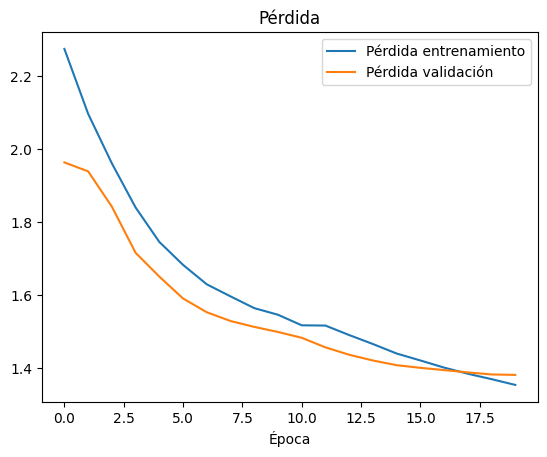

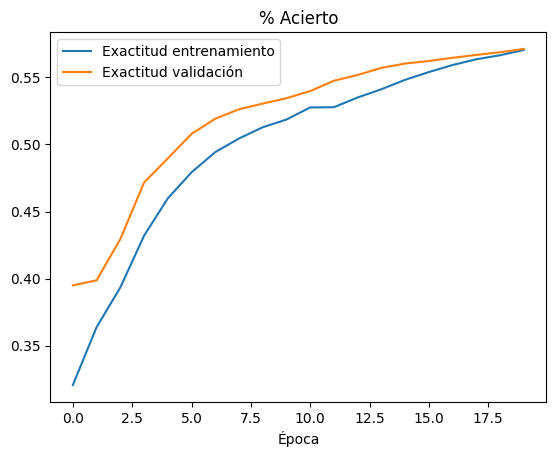

In [ ]:
# Mostramos la pérdida y el acierto por cada época

plt.plot(hist_test1.history['loss'], label='Pérdida entrenamiento')
plt.plot(hist_test1.history['val_loss'], label='Pérdida validación')
plt.legend()
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(hist_test1.history['accuracy'], label='Exactitud entrenamiento')
plt.plot(hist_test1.history['val_accuracy'], label='Exactitud validación')
plt.legend()
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

**Perdida**: Se comprenden buenos niveles de pérdida sobre el modelo base, los cuales se mantienen en niveles tanto en el entrenamiento como en la validación. Se demuestra de forma breve como es que la perdida en la validación tiende a ser ligeramente mejor que la de entrenamiento.

**Aciertos**: Ambas lineas suben de forma constante hasta mantenerse ligeramente aplanadas en la época 20, con un valor cercano al 0.55. Estos valores pueden sugerir que el modelo puede seguir siendo mejorado.

##Segundo entrenamiento

Como segunda configuración, se decidieron aumentar los valores para identificar si es que el modelo logra aprender más sobre los datos. Con más epochs y un batch_size mayor, la configuración busca comprender si es que este aumento realiza cambios significativos sobre el modelo.

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

# Configuración 2 - base
modelo_test2 = crear_modelo()

hist_test2 = modelo_test2.fit(
    X_train, y_train,
    batch_size=256,
    epochs=50,
    validation_data=(X_val, y_val)
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 58s 41ms/step - accuracy: 0.2972 - loss: 2.3829 - val_accuracy: 0.3723 - val_loss: 2.0535
Epoch 2/50
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 54s 39ms/step - accuracy: 0.3804 - loss: 2.0119 - val_accuracy: 0.4203 - val_loss: 1.8746
Epoch 3/50
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 54s 39ms/step - accuracy: 0.4203 - loss: 1.8803 - val_accuracy: 0.4573 - val_loss: 1.7615
Epoch 4/50
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 54s 39ms/step - accuracy: 0.4533 - loss: 1.7801 - val_accuracy: 0.4865 - val_loss: 1.6680
Epoch 5/50
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 54s 40ms/step - accuracy: 0.4543 - loss: 1.7856 - val_accuracy: 0.4797 - val_loss: 1.6864
Epoch 6/50
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 55s 40ms/step - accuracy: 0.4644 - loss: 1.7392 - val_accuracy: 0.4832 - val_loss: 1.6721
Epoch 7/50
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 56s 41ms/step - accuracy: 0.4704 - loss: 1.7130 - val_accuracy: 0.5022 - val_loss: 1.6077
Epoch 8/50
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 54s 40ms/step - accuracy: 0.5081 -

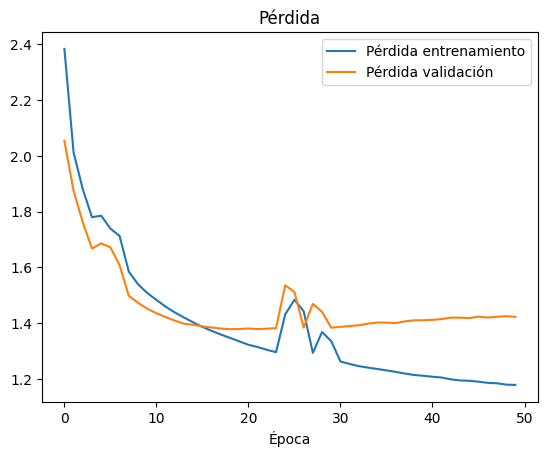

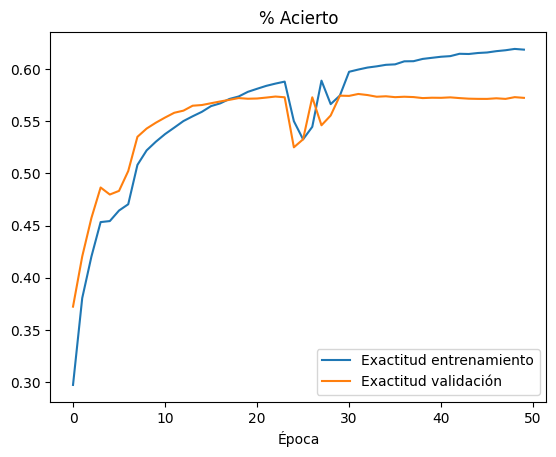

In [ ]:
# Mostramos la pérdida y el acierto por cada época

plt.plot(hist_test2.history['loss'], label='Pérdida entrenamiento')
plt.plot(hist_test2.history['val_loss'], label='Pérdida validación')
plt.legend()
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(hist_test2.history['accuracy'], label='Exactitud entrenamiento')
plt.plot(hist_test2.history['val_accuracy'], label='Exactitud validación')
plt.legend()
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

**Perdida**: A pesar de mantener una perdida constante tanto en entrenamiento como en validación, se es posible ver como es que los valores suben u bajan de golpe, para luego visualizar como las lineas de entrenamiento y validación se dividen, demostrando que el modelo dejó de aprender a partir de los datos.

**Acierto**: de forma similar a la perdida, mantiene valores constantes tanto en entrenamiento como en la validación, manteniendose hasta que cerca de la época 25 estos bajan abrutamente y vuelven a aumentar, con la misma separación de lineas entre entrenamiento y validación. Esto es un claro signo de overfitting.

##Conclusiones parciales

*   El incremento de hiperparámetros en el segundo entrenamiento reveló que alrededor de la epoca 25 existe cierta divergencia entre las lineas de entrenamiento y validación, en conjunto con una disminución abrupta de los valores. Este cambio puede deberse a una inadaptabilidad del learning rate en base al batch_size.
*   En este caso, el aumento de los parámetros logró demostrar que estos no hacen una mejora en el modelo, por lo que se ha decidido **mantener un batch_size de 128**, en conjunto con una **disminución del learning rate** para evitar bajas de golpe en el entrenamiento. Por otro lado, también buscaremos aplicar un **aumento del dropout** para evitar depender de forma completa de ciertas neuronas, apoyando el aprendizaje costoso del modelo. Finalmente, se decidió **mantener las 50 épocas** para poder visualizar cambios de forma sostenida.



#Aplicación de cambios en el modelo

In [ ]:
#Aplicación de las semillas
np.random.seed(42)
tf.random.set_seed(42)

#Se aplica la configuración 3 con las mejroas anteriormente mencionadas
modelo_test4 = crear_modelo(units_1=256, units_2=64, dropout=0.25, learning_rate=0.0002)

hist_test4 = modelo_test4.fit(
    X_train, y_train,
    batch_size=128,
    epochs=50,
    validation_data=(X_val, y_val)
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
2735/2735 ━━━━━━━━━━━━━━━━━━━━ 75s 26ms/step - accuracy: 0.2504 - loss: 2.6491 - val_accuracy: 0.3294 - val_loss: 2.2530
Epoch 2/50
2735/2735 ━━━━━━━━━━━━━━━━━━━━ 74s 24ms/step - accuracy: 0.3287 - loss: 2.2212 - val_accuracy: 0.3631 - val_loss: 2.1061
Epoch 3/50
2735/2735 ━━━━━━━━━━━━━━━━━━━━ 65s 24ms/step - accuracy: 0.3554 - loss: 2.1145 - val_accuracy: 0.3828 - val_loss: 2.0148
Epoch 4/50
2735/2735 ━━━━━━━━━━━━━━━━━━━━ 65s 24ms/step - accuracy: 0.3744 - loss: 2.0429 - val_accuracy: 0.4004 - val_loss: 1.9525
Epoch 5/50
2735/2735 ━━━━━━━━━━━━━━━━━━━━ 65s 24ms/step - accuracy: 0.3907 - loss: 1.9869 - val_accuracy: 0.4132 - val_loss: 1.9005
Epoch 6/50
2735/2735 ━━━━━━━━━━━━━━━━━━━━ 65s 24ms/step - accuracy: 0.4049 - loss: 1.9385 - val_accuracy: 0.4287 - val_loss: 1.8525
Epoch 7/50
2735/2735 ━━━━━━━━━━━━━━━━━━━━ 66s 24ms/step - accuracy: 0.4167 - loss: 1.8992 - val_accuracy: 0.4411 - val_loss: 1.8135
Epoch 8/50
2735/2735 ━━━━━━━━━━━━━━━━━━━━ 82s 24ms/step - accuracy: 0.4266 -

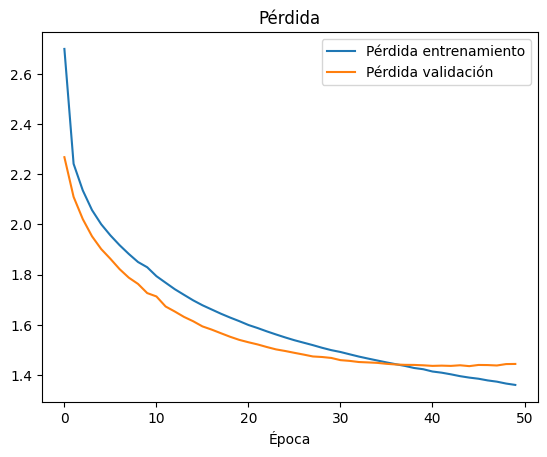

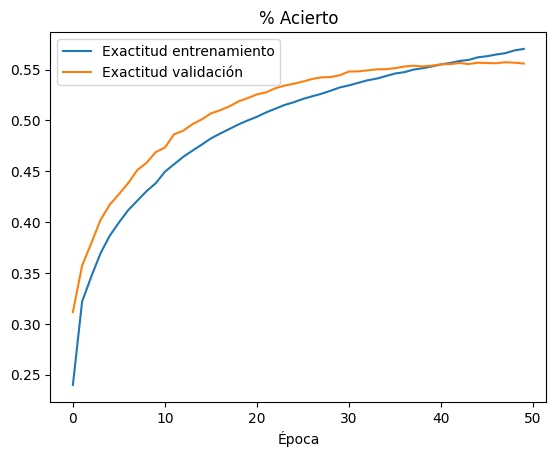

In [ ]:
# Mostramos la pérdida y el acierto por cada época

plt.plot(hist_test4.history['loss'], label='Pérdida entrenamiento')
plt.plot(hist_test4.history['val_loss'], label='Pérdida validación')
plt.legend()
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(hist_test4.history['accuracy'], label='Exactitud entrenamiento')
plt.plot(hist_test4.history['val_accuracy'], label='Exactitud validación')
plt.legend()
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

En este caso, al probar con diferentes hiperparámetros sobre el modelo, podemos comprender que el haber forzado un aprendizaje más costoso, en conjunto con el aumento del learning rate y el haber mantenido una cantidad alta de épocas no ha generado cambios significativos sobre el accuracy y la pérdida en base a lo que se ha construido en el primer modelo entrenado. Esto puede significar que no pueden realizarse más mejoras en base a los resultados del modelo, comprendiendo que al tener que predecir y generar el siguiente conjunto de palabras no se puede definir un contexto definitivo para indicar que existe una palabra correcta para seguir una narrativa dada.

Ejemplo de este caso seria una frase aleatoria como "cada uno es artifice de su propia -", donde puede darle continuación con variados ejemplos, como "ventura", "vida", "miseria", etc.

Debido a estos resultados previos, se continuará para dar paso a a lo que es la evaluación del modelo final.

#Evaluación del modelo

Para la evaluación del modelo seleccionado se aplicaron las métricas de accuracy, precision, recall y f1-score, con el propósito de comprender como es que está funcionando el modelo con el diccionario dado.

In [ ]:
# Predicciones
y_pred = modelo_test4.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)
y_val_classes  = np.argmax(y_val, axis=1)

# Etiquetas de los carácteres
labels = sorted(set(y_val_classes) | set(y_pred_classes))

def mostrar(c):
    if c == ' ':
        return "'·' (espacio)"
    return f"'{c}'"

target_names = [mostrar(index_to_char[i]) for i in labels]

print(classification_report(
    y_val_classes, y_pred_classes,
    labels=labels,
    target_names=target_names,
    zero_division=0
))

2344/2344 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step
               precision    recall  f1-score   support

'·' (espacio)       0.74      0.90      0.81     13700
          '!'       0.00      0.00      0.00        39
          ','       0.39      0.12      0.19      1489
          '-'       0.49      0.65      0.56       248
          '.'       0.67      0.02      0.04       283
          ':'       0.72      0.25      0.37        85
          ';'       0.00      0.00      0.00       170
          '?'       0.00      0.00      0.00        25
          'a'       0.52      0.59      0.55      6954
          'b'       0.47      0.39      0.43       866
          'c'       0.29      0.32      0.30      2085
          'd'       0.32      0.53      0.40      3211
          'e'       0.53      0.66      0.59      7854
          'f'       1.00      0.00      0.01       261
          'g'       0.48      0.23      0.31       677
          'h'       0.65      0.32      0.43       689
          'i'       

A partir de los resultados, podemos interpretar los siguientes elementos:

*   Se comprende una gran diferencia de valores entre el **macro avg y el weighted avg** (49-31-34/56-56-54, respectivamente). Esto puede deberse a la diferencia de uso entre los carácteres del vocabulario español, en este caso, se puede denotar que existen caracteres mucho más usados que otros a la hora de generar textos (ejemplo de esta diferencia puede ser el gran uso de vocales, a diferencia de la letra "z".)
*   Cuando se revisan las métricas de los carácteres de forma individual, se es posible comprender que el modelo tiene una gran capacidad de predicción por sobre los espacios debido a su gran uso en textos para separar palabras. Estos resultados se ven seguidos por un promedio de predicción de vocales y consonantes, las cuales son usadas de forma frecuente para generar las palabras. Finalmente, existen otros carácteres que no han sido usados con tanta frecuencia, que denotan que son muy situacionales y que el modelo sacrifica de las generaciones de texto comunes.
*   El accuracy del modelo se define con un valor de 0.56, indicando que el modelo tiene una buena capadidad de predicción sobre los carácteres, tomando en cuenta los variados usos del lenguaje en el español y los miles de casos que pueden aplicarse a la hora de generar palabras para un texto.





#Visualización de resultados

In [ ]:
#A partir del uso de la temperatura, se puede variar la capacidad de generación de texto del modelo
#Es decir, mientras menor sea la temperatura, será menos creativo y más repetitivo
#Si la temperatura es mayor, es más creativo, pero es más propenso a cometer errores
def sample(preds, temperature=1.0):
    preds = np.asarray(preds).astype('float64')
    preds = np.log(preds + 1e-9) / temperature
    exp_preds = np.exp(preds)
    preds = exp_preds / np.sum(exp_preds)
    probas = np.random.multinomial(1, preds, 1)
    return np.argmax(probas)

#Función para generar texto, caráctes a carácter
def generar_texto(modelo, semilla, longitud=400, temperature=1.0):
    generado = semilla
    sentence = semilla

    for _ in range(longitud):
        x_pred = np.zeros((1, seq_length, vocab_size))
        for t, char in enumerate(sentence):
            x_pred[0, t, char_to_index[char]] = 1.0

#El modelo predice la distribución del siguiente carácter
        preds = modelo.predict(x_pred, verbose=0)[0]

#Se muestrea el carácter y se traduce de inedx a carácter
        next_index = sample(preds, temperature)
        next_char = index_to_char[next_index]

#El carácter es agregado al resto del texto
        generado += next_char
        sentence = sentence[1:] + next_char

    return generado

#Se elige una semilla aleatoria
np.random.seed(42)
start_index = np.random.randint(0, len(text_lower) - seq_length - 1)
semilla = text_lower[start_index: start_index + seq_length]

print("=" * 70)
print("SEMILLA INICIAL (texto real de Don Quijote):")
print("=" * 70)
print(f'"{semilla}"\n')

#Se generan los textos con las temperaturas diferentes
for temp in [0.2, 0.5, 1.0]:
    print("=" * 70)
    print(f"TEXTO GENERADO  |  temperatura = {temp}")
    print("=" * 70)
    texto = generar_texto(modelo_test4, semilla, longitud=400, temperature=temp)
    print(texto[seq_length:])
    print("\n")

SEMILLA INICIAL (texto real de Don Quijote):
" consigo. ansí que, señor mío, estas honras que vuestra merced quiere darme por ser ministro y adher"

TEXTO GENERADO  |  temperatura = 0.2
esto de la mano por el caballero de la mano de la mano de mi parecer, y el pasar llegarme a la menos, que el cuento de la parte de la verdad de la mano de la caballería, y al caballero de la parte de la caballería de la caballería, y al parecer de la mano de la mano, y con su casa de las de la caballería de la mancha, que en este la mano de la mano de la caballería de la caballería de la mancha, y


TEXTO GENERADO  |  temperatura = 0.5
es, muchos cortestos y endrandoses y a su suerte por parecerles de la contancia, y le peres, que por las malas y por su parte de la gamas, y allí le sucedía a los trastos de mi principa. y en el agra entrado nuestro hermona de nadua, y hallaron de la señora, andan el mundo el cielo, su puedto y cantante en los voyos de la cual quiere serced, mandares, porque en su ventano

#Conclusiones

*   El modelo fue capaz de alcanzar un accuracy que ronda alrededor de un 55-56%, con una pérdida del 1.4% demostrando así una buena capacidad de predicción por sobre los carácteres del alfabeto español.
*   Los resultados visuales del modelo fueron capaces de demostrar con certeza que este puede identificar letras para formar palabras coherentes del lenguaje, donde las temperaturas variaron su "creatividad", pero a su vez demostrando que también es propenso a cometer errores y formar palabras sin sentido.
*   Por otro lado, a través de las métricas pudimos identificar que elementos o carácteres son más propensos a ser utilizados por el modelo debido a su capacidad de identificación por sobre estos. Entre estos elementos destacan los espaciados entre palabra y palabra y vocales en conjunto con consonantes.
*   Se recomienda trabajar con un Transformeer por sobre los datos con la intención de verificar si es que se es posible mejorar los resultados del modelo.





